In [ ]:
#Import necessary packages

import os
import keras
from keras.applications import inception_v3 as inc_net
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
print("Notebook run using keras:", keras.__version__)

Notebook run using keras: 3.13.2


In [ ]:
inet_model=inc_net.InceptionV3()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def transform_img_fn(path_list):
  out=[]
  for img_path in path_list:
    img=image.load_img(img_path,target_size=(299,299))
    x=image.img_to_array(img)
    x=np.expand_dims(x,axis=0)
    x=inc_net.preprocess_input(x)
    out.append(x)
  return np.vstack(out)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
('n01871265', 'tusker', np.float32(0.5848367))
('n02504458', 'African_elephant', np.float32(0.22708978))
('n02504013', 'Indian_elephant', np.float32(0.087025724))
('n02823750', 'beer_glass', np.float32(0.00035678787))
('n04033995', 'quilt', np.float32(0.0003509957))


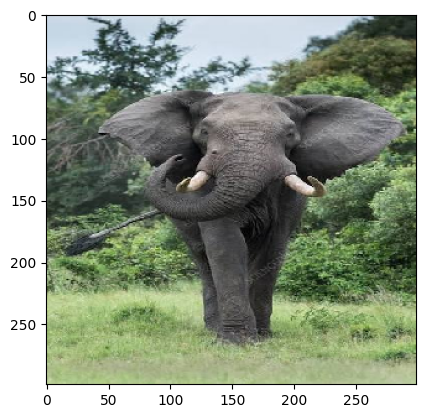

In [ ]:
#Lets see top 5 predictions for some emage

images=transform_img_fn([os.path.join("/content/drive/MyDrive/imgdata/Afr_elep.jpg")])

#Dividing by 2 and adding 0.5 because of how this Inception represents image
plt.imshow(images[0]/2 + 0.5 )
preds=inet_model.predict(images)
for x in decode_predictions(preds)[0]:
  print(x)

Explanation

In [ ]:
pip install lime

In [ ]:
import os, sys

import lime

from lime import lime_image

In [ ]:
explainer=lime_image.LimeImageExplainer()

In [ ]:
%%time

explanation=explainer.explain_instance(images[0].astype('double'), inet_model.predict, top_labels=5, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 

In [ ]:
#Now let's see the explanation for the top class
from skimage.segmentation import mark_boundaries

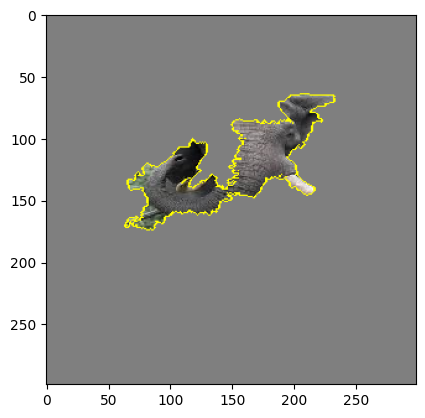

In [ ]:
#Hiding the rest of the image
temp, mask=explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))

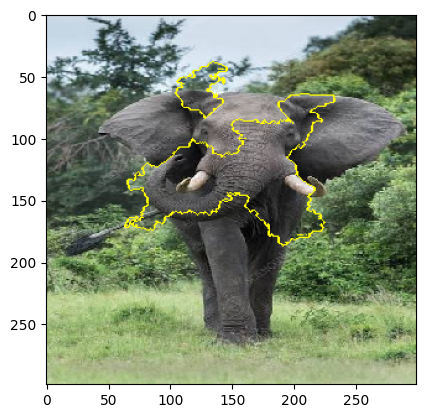

In [ ]:
#Or with the rest of the image present

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=8, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

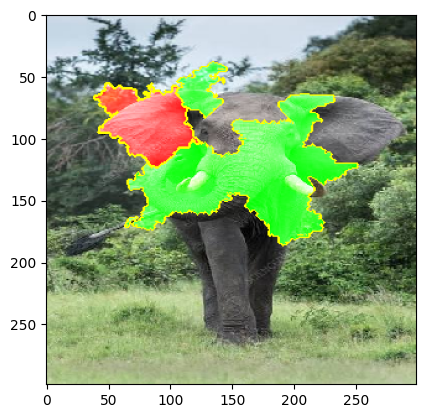

In [ ]:
#pros and cons
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

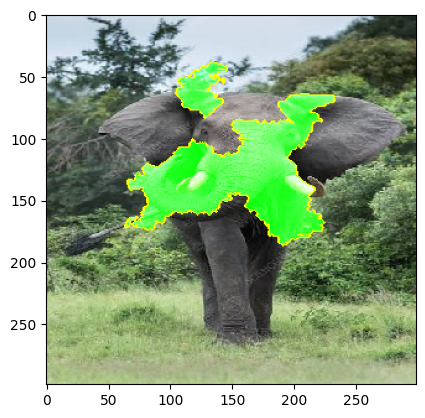

In [ ]:
#Or the pros and cons with atleas weight 0.1
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=1000, hide_rest=False, min_weight=0.035)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

In [ ]:
!pip install gradio lime

import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from lime import lime_image
from keras.applications import inception_v3 as inc_net
from keras.applications.imagenet_utils import decode_predictions

inet_model = inc_net.InceptionV3()
explainer = lime_image.LimeImageExplainer()

def predict_and_explain(input_image):
    # Gradio gives us a numpy array directly — resize + preprocess like transform_img_fn did
    img = np.array(input_image.resize((299, 299)))
    x = np.expand_dims(img, axis=0)
    x = inc_net.preprocess_input(x.astype('float'))

    # Prediction
    preds = inet_model.predict(x)
    top5 = decode_predictions(preds)[0]
    pred_text = "\n".join([f"{label}: {round(float(prob)*100, 2)}%" for (_, label, prob) in top5])

    # LIME explanation
    explanation = explainer.explain_instance(
        x[0].astype('double'), inet_model.predict,
        top_labels=5, hide_color=0, num_samples=500, batch_size=50
    )

    def get_vis(**kwargs):
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], **kwargs)
        return mark_boundaries(temp / 2 + 0.5, mask)

    vis1 = get_vis(positive_only=True, num_features=5, hide_rest=True)
    vis2 = get_vis(positive_only=True, num_features=8, hide_rest=False)
    vis3 = get_vis(positive_only=False, num_features=10, hide_rest=False)
    vis4 = get_vis(positive_only=False, num_features=1000, hide_rest=False, min_weight=0.035)

    return pred_text, vis1, vis2, vis3, vis4

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="pil", label="Upload an image"),
    outputs=[
        gr.Textbox(label="Top 5 Predictions"),
        gr.Image(label="Top feature only (hidden background)"),
        gr.Image(label="Top features (with background)"),
        gr.Image(label="Positive + negative regions"),
        gr.Image(label="Weighted threshold view (min_weight=0.035)")
    ],
    title="InceptionV3 + LIME: Why did the model predict this?",
    description="Upload an image and see which regions InceptionV3 used to make its top prediction, explained via LIME."
)

demo.launch()